In [1]:
# --- All imports collected and organized at the top ---
# Core scientific libraries
import os 
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # Disable XLA preallocation to prevent OOM errors
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.1"  # Limit XLA to use at most 80% of GPU memory

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

import jax 

# Pyramid core imports
import pyramid as pr
from pyramid.magcreator.shapes import disc
from pyramid.magcreator.magcreator import create_mag_dist_homog
from pyramid.fielddata import VectorData
from pyramid.projector import SimpleProjector
from pyramid.phasemapper import PhaseMapperRDFC
from pyramid.utils.convenience import reconstruction_2d_from_phasemap
from pyramid.phasemap import PhaseMap
from pyramid.kernel import Kernel

# LiberTEM-holo MBIR imports
from libertem_holo.base.mbir import (
    forward_model_2d,
    lcurve_sweep_vmap,
    reconstruct_2d,
 )

jax.config.update("jax_enable_x64", True)  # Enable 64-bit precision in JAX

%matplotlib widget

# Synthetic Magnetisation Reconstruction with Pyramid
This notebook demonstrates the workflow for generating a synthetic magnetisation distribution, simulating phase maps, and reconstructing the magnetisation using the Pyramid library.

---


In [2]:
N = 128
dim = (N, N, N)
center = (N//2, N//2, N//2)
R = 40
H = 17
px_size = 7.423
mag_shape = disc(dim=dim, center=center, radius=R, height=H)
disc_uni = create_mag_dist_homog(mag_shape=mag_shape, phi=np.pi/2)
b_0 = 4.312
max_iter = 1000

## 1. Create Synthetic Magnetisation Distribution
We define a synthetic disc-shaped magnetisation distribution for testing.

In [3]:
mag_distrib = VectorData(a=px_size, field=disc_uni)

### Visualize Magnetisation Components
Display the three components of the synthetic magnetisation in the central slice.

Text(0.5, 1.0, '$M_z$ (central slice)')

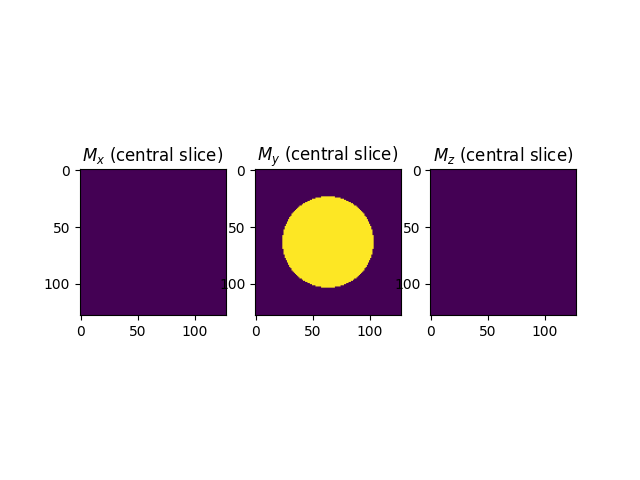

In [4]:
fig, ax = plt.subplots(ncols=3)

ax[0].imshow(mag_distrib.field[0, N//2, ...], vmin=0.0, vmax=1.0)
ax[0].set_title("$M_x$ (central slice)")
ax[1].imshow(mag_distrib.field[1, N//2, ...], vmin=0.0, vmax=1.0)
ax[1].set_title("$M_y$ (central slice)")
ax[2].imshow(mag_distrib.field[2, N//2, ...], vmin=0.0, vmax=1.0)
ax[2].set_title("$M_z$ (central slice)")

In [5]:
projector = SimpleProjector(mag_distrib.dim, axis='z')
kern = Kernel(mag_distrib.a, projector.dim_uv, b_0=b_0, geometry="disc")
phasemapper = PhaseMapperRDFC(kern)
field_proj = projector(mag_distrib)
phasemap = phasemapper(field_proj)
phasemap.mask = field_proj.get_mask()[0, ...]

## 2. Simulate Phase Map
Project the synthetic magnetisation and simulate the phase map using the forward model.

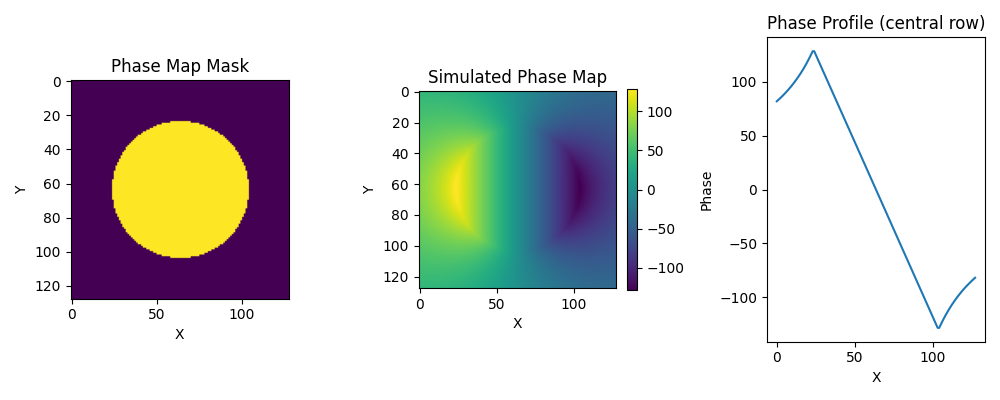

In [6]:
fig, ax = plt.subplots(ncols=3, figsize=(10,4))

ax[0].imshow(phasemap.mask)
ax[0].set_title("Phase Map Mask")
ax[0].set_xlabel("X")
ax[0].set_ylabel("Y")

im1 = ax[1].imshow(phasemap.phase)
ax[1].set_title("Simulated Phase Map")
ax[1].set_xlabel("X")
ax[1].set_ylabel("Y")
plt.colorbar(im1, ax=ax[1], fraction=0.046)

ax[2].plot(phasemap.phase[N//2, ...])
ax[2].set_title("Phase Profile (central row)")
ax[2].set_xlabel("X")
ax[2].set_ylabel("Phase")

plt.tight_layout()

### Visualize Phase Map and Mask
Show the simulated phase map and the mask used for further processing.

In [7]:
phase_mag = phasemap.phase
phase_mip = phasemap.mask

Mask covers 5024 / 16384 pixels (30.7%)


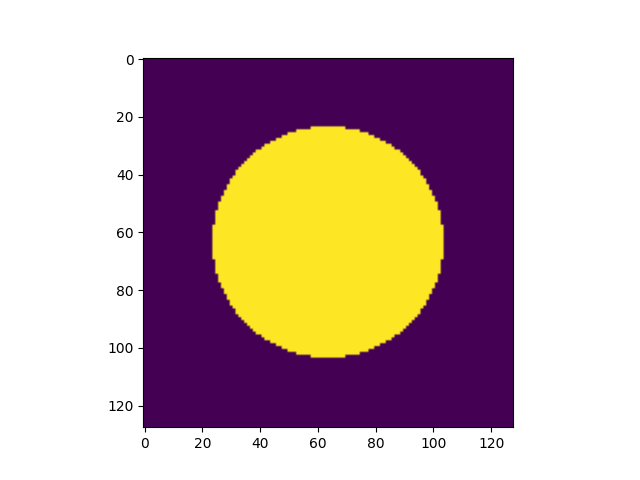

In [8]:
mip_threshold = 0.1
mask = (np.abs(phase_mip) > mip_threshold).astype(np.float64)
plt.figure()
plt.imshow(mask)
print(f"Mask covers {mask.sum():.0f} / {mask.size} pixels "
      f"({100 * mask.mean():.1f}%)")

phasemap = pr.PhaseMap(a=px_size, phase=phase_mag, mask=mask)
dim = (1,) + phasemap.dim_uv

# Pass the disc mask to DataSet so Pyramid optimizes only inside the disc,
# matching MBIR's `mag * mask` behaviour.  Without this, Pyramid defaults to
# an all-True mask (full grid) which gives very different L-curve values.
mask_3d = mask.astype(bool)[None, ...]  # shape (1, H, W)
data_set = pr.DataSet(phasemap.a, dim=dim, b_0=b_0, mask=mask_3d)

# Pass a PhaseMapperRDFC explicitly so Pyramid's ForwardModel uses the same
# forward model as MBIR (zero-padded linear convolution, not periodic FDFC).
kern_pyr_rdfc = Kernel(px_size, phasemap.dim_uv, b_0=b_0, geometry="disc")
phasemapper_rdfc = PhaseMapperRDFC(kern_pyr_rdfc)
data_set.append(phasemap, pr.SimpleProjector(dim=dim), phasemapper=phasemapper_rdfc)

## 3. Prepare Data for Reconstruction
Apply a mask to the phase map and prepare the dataset for the forward model.

In [9]:
ramp_order = 1
fwd_model = pr.ForwardModel(data_set, ramp_order=ramp_order)

## 4. Forward Model and L-Curve Analysis
Set up the forward model and perform L-curve analysis to select the regularization parameter.

In [10]:
lambdas = np.logspace(-6, -1, num=5)
lcurve = pr.LCurve(fwd_model, max_iter=max_iter, save_dir=None)

lcurve.calculate(lambdas)

x_lcurve_pyramid = [lcurve.l_dict[lam][0] for lam in lambdas]
y_lcurve_pyramid = [lcurve.l_dict[lam][1] / lam for lam in lambdas]

lcurve.plot(lambdas)

  0%|          | 0/5 [00:00<?, ?it/s]

CG:   0%|          | 0/1000 [00:00<?, ?it/s]

CG:   0%|          | 0/1000 [00:00<?, ?it/s]

CG:   0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 5. 2D Reconstruction from Phase Map
Use the selected regularization parameter to reconstruct the 2D magnetisation distribution from the phase map.

In [ ]:
best_lam = 1e-4

pm = PhaseMap(a=px_size, phase=np.asarray(phase_mag), mask=mask)
magdata_pyr, cost_pyr = reconstruction_2d_from_phasemap(
    pm, b_0=b_0, lam=best_lam, max_iter=max_iter,
    ramp_order=None, verbose=True,
    )

CG:   0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
u_pyr = magdata_pyr.field[0,0,...]
v_pyr = magdata_pyr.field[1,0,...]
mag_abs_pyr = magdata_pyr.field_amp[0,...]

### Extract Magnetisation Components
Extract the reconstructed $M_x$, $M_y$, and $|M|$ components from the result.

### Normalization Check for Pyramid Reconstruction
To ensure Pyramid's reconstructed magnetization is correctly normalized, the following points are critical:
- The synthetic phase and the reconstruction must use the same forward model (e.g., both RDFC).
- The mask must cover the full region of nonzero magnetization.
- The expected projected $|M|$ is the sum of per-voxel $|M|$ along the projection axis (e.g., height $H$ for a disc with $|M|=1$ per voxel).
- All physical parameters (voxel size, $b_0$, etc.) must be consistent.

The next cell prints the mean and max $|M|$ inside the mask and compares to the expected value.

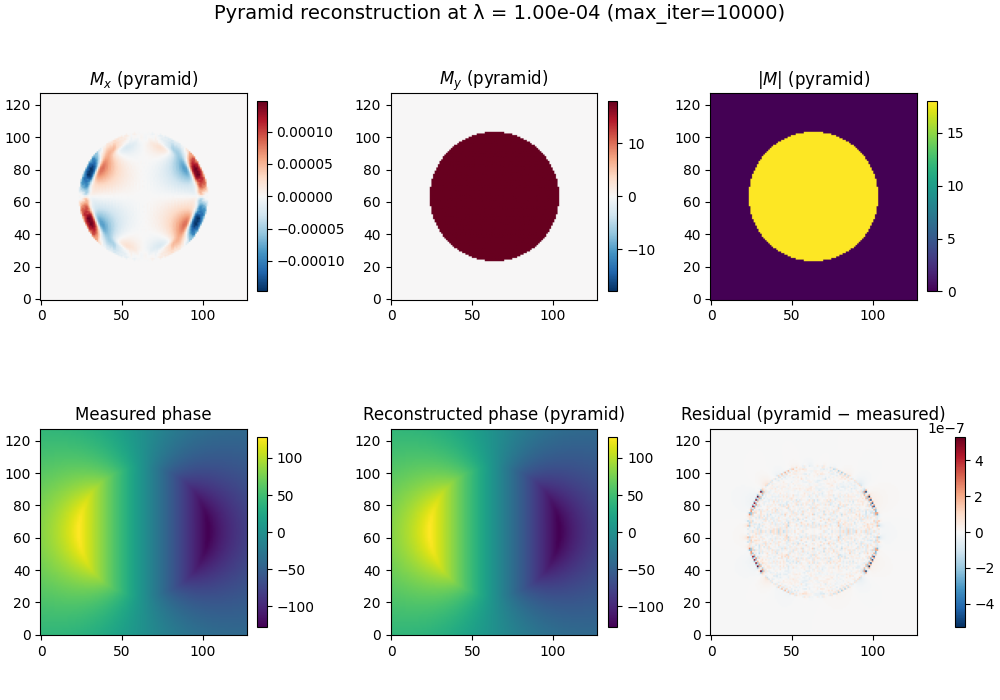

Pyramid residual RMS: 0.000000


In [ ]:
# Pyramid result: same 2×3 layout as libertem_holo

# Forward-model pyramid's reconstruction to get predicted phase
kern_pyr = Kernel(px_size, phase_mag.shape, b_0=b_0, geometry="disc")
mapper_pyr = PhaseMapperRDFC(kern_pyr)
field_pyr = np.zeros((3, 1) + phase_mag.shape)
field_pyr[0, 0] = u_pyr
field_pyr[1, 0] = v_pyr
pred_pyr = mapper_pyr(VectorData(px_size, field_pyr)).phase
residual_pyr = pred_pyr - phase_mag

fig, axs = plt.subplots(2, 3, figsize=(10, 7), constrained_layout=True)

# Row 1: magnetisation components

vmax_u = max(np.abs(u_pyr).max(), 1e-12)
vmax_v = max(np.abs(v_pyr).max(), 1e-12)

im = axs[0, 0].imshow(u_pyr, cmap="RdBu_r", origin="lower",
                        norm=TwoSlopeNorm(0, -vmax_u, vmax_u))
axs[0, 0].set_title(r"$M_x$ (pyramid)")
plt.colorbar(im, ax=axs[0, 0], fraction=0.046)

im = axs[0, 1].imshow(v_pyr, cmap="RdBu_r", origin="lower",
                        norm=TwoSlopeNorm(0, -vmax_v, vmax_v))
axs[0, 1].set_title(r"$M_y$ (pyramid)")
plt.colorbar(im, ax=axs[0, 1], fraction=0.046)

im = axs[0, 2].imshow(mag_abs_pyr, cmap="viridis", origin="lower")
axs[0, 2].set_title(r"$|M|$ (pyramid)")
plt.colorbar(im, ax=axs[0, 2], fraction=0.046)

# Row 2: phase comparison
vmin_p = min(np.nanmin(phase_mag), np.nanmin(pred_pyr))
vmax_p = max(np.nanmax(phase_mag), np.nanmax(pred_pyr))

im = axs[1, 0].imshow(phase_mag, cmap="viridis", origin="lower", vmin=vmin_p, vmax=vmax_p)
axs[1, 0].set_title("Measured phase")
plt.colorbar(im, ax=axs[1, 0], fraction=0.046)

im = axs[1, 1].imshow(pred_pyr, cmap="viridis", origin="lower", vmin=vmin_p, vmax=vmax_p)
axs[1, 1].set_title("Reconstructed phase (pyramid)")
plt.colorbar(im, ax=axs[1, 1], fraction=0.046)

dmax_p = max(np.abs(residual_pyr).max(), 1e-12)
im = axs[1, 2].imshow(residual_pyr, cmap="RdBu_r", origin="lower", vmin=-dmax_p, vmax=dmax_p)
axs[1, 2].set_title("Residual (pyramid − measured)")
plt.colorbar(im, ax=axs[1, 2], fraction=0.046)

fig.suptitle(f"Pyramid reconstruction at λ = {best_lam:.2e} (max_iter=10000)", fontsize=14)
plt.show()

print(f"Pyramid residual RMS: {np.sqrt(np.mean(residual_pyr**2)):.6f}")
#print(f"LT-holo residual RMS: {np.sqrt(np.mean((np.asarray(pred_phase) - mag_phase)**2)):.6f}")

## 7. MBIR Solution with LiberTEM-holo
Now we reconstruct the magnetisation using the MBIR method from `libertem_holo.base.mbir` and compare it to the Pyramid solution.

In [ ]:
lambdas_mbir = np.logspace(-6, 2, num=10)
lc_mbir = lcurve_sweep_vmap(
    phase=phase_mag,
    mask=mask,
    voxel_size_nm=px_size,
    lambdas=lambdas_mbir,
    b0_tesla=b_0,
    solver="newton_cg",
    pyramid_compat=True,
    thickness=H
)

print(f"MBIR L-curve corner: index {lc_mbir.corner_index} (lambda = {lc_mbir.lambdas[lc_mbir.corner_index]:.3e})")

MBIR L-curve corner: index 3 (lambda = 4.642e-04)


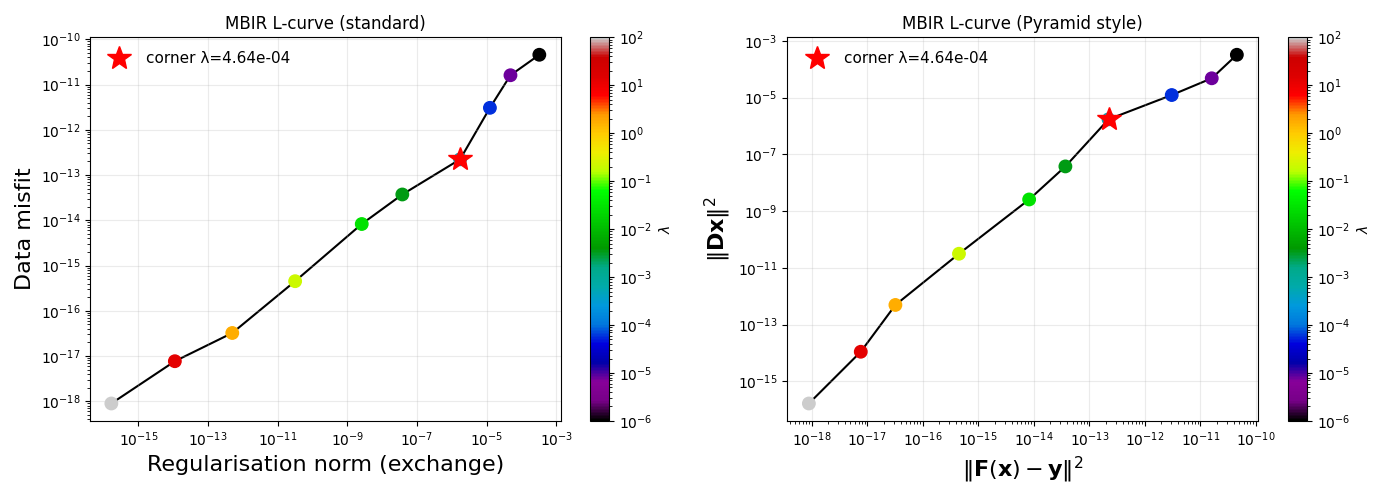

In [ ]:
# --- Plot MBIR L-curve (standard and Pyramid style) ---
from libertem_holo.base import mbir as mbir_mod
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
mbir_mod.plot_lcurve(lc_mbir, pyramid_style=False, ax=axs[0])
axs[0].set_title("MBIR L-curve (standard)")
mbir_mod.plot_lcurve(lc_mbir, pyramid_style=True, ax=axs[1])
axs[1].set_title("MBIR L-curve (Pyramid style)")
plt.tight_layout()
plt.show()

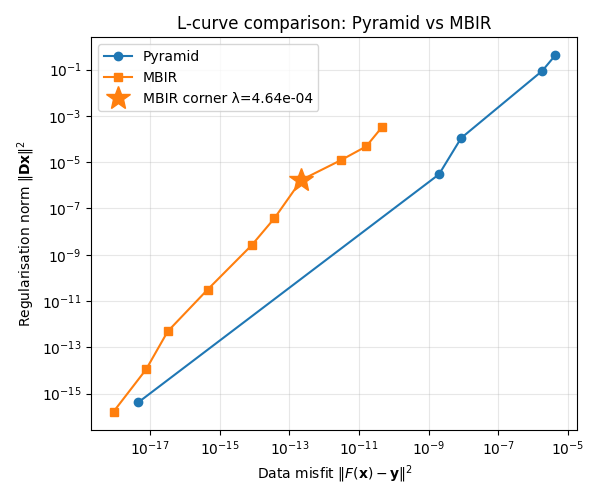

In [ ]:
# --- Overlay L-curve comparison: Pyramid vs MBIR ---
fig, ax = plt.subplots(figsize=(6, 5))

# Pyramid L-curve (x = data misfit, y = reg norm)
ax.loglog(x_lcurve_pyramid, y_lcurve_pyramid, 'o-', color='tab:blue', label='Pyramid')

# MBIR L-curve (pyramid_compat=True → forward_diff_norm, same metric)
ax.loglog(lc_mbir.data_misfits, lc_mbir.reg_norms, 's-', color='tab:orange', label='MBIR')

# Mark corners
corner_idx_pyr = lcurve.corner_idx if hasattr(lcurve, 'corner_idx') else None
corner_idx_mbir = lc_mbir.corner_index

if corner_idx_mbir is not None:
    ax.plot(lc_mbir.data_misfits[corner_idx_mbir],
            lc_mbir.reg_norms[corner_idx_mbir],
            '*', ms=18, color='tab:orange', zorder=5, label=f'MBIR corner λ={lc_mbir.lambdas[corner_idx_mbir]:.2e}')

ax.set_xlabel(r'Data misfit $\|F(\mathbf{x}) - \mathbf{y}\|^2$')
ax.set_ylabel(r'Regularisation norm $\|\mathbf{Dx}\|^2$')
ax.set_title('L-curve comparison: Pyramid vs MBIR')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [ ]:
# --- Final MBIR reconstruction at optimal lambda ---
best_lam_mbir = lc_mbir.lambdas[lc_mbir.corner_index]

result_mbir = reconstruct_2d(
    phase=phase_mag,
    voxel_size_nm=px_size,
    b0_tesla=1.0,
    mask=mask,
    lam=best_lam_mbir,
    solver="newton_cg",
    thickness=H
)

best_mag_mbir = result_mbir.magnetization
best_ramp_mbir = result_mbir.ramp_coeffs

# Forward-model the best MBIR reconstruction to get the predicted phase
# (thickness= H converts per-voxel M back to projected before forward model)
pred_phase_mbir = forward_model_2d(
    best_mag_mbir, px_size,
    b0_tesla=1.0, ramp_coeffs=best_ramp_mbir,
    thickness=H,
)

print(f"Best MBIR lambda: {best_lam_mbir:.3e}")
print(f"Final MBIR loss:  {float(result_mbir.loss_history[-1]):.3e}")
print()
inside = mask > 0.5
mag_norm_mbir = np.sqrt(
    np.asarray(best_mag_mbir[..., 0])**2 + np.asarray(best_mag_mbir[..., 1])**2
)
print(f"Per-voxel |M| mean inside mask: {mag_norm_mbir[inside].mean():.4f}  (expected ≈ 1.0)")
print(f"Per-voxel |M| max inside mask:  {mag_norm_mbir[inside].max():.4f}")

Best MBIR lambda: 4.642e-04
Final MBIR loss:  1.317e-12

Per-voxel |M| mean inside mask: 4.5656  (expected ≈ 1.0)
Per-voxel |M| max inside mask:  4.5656


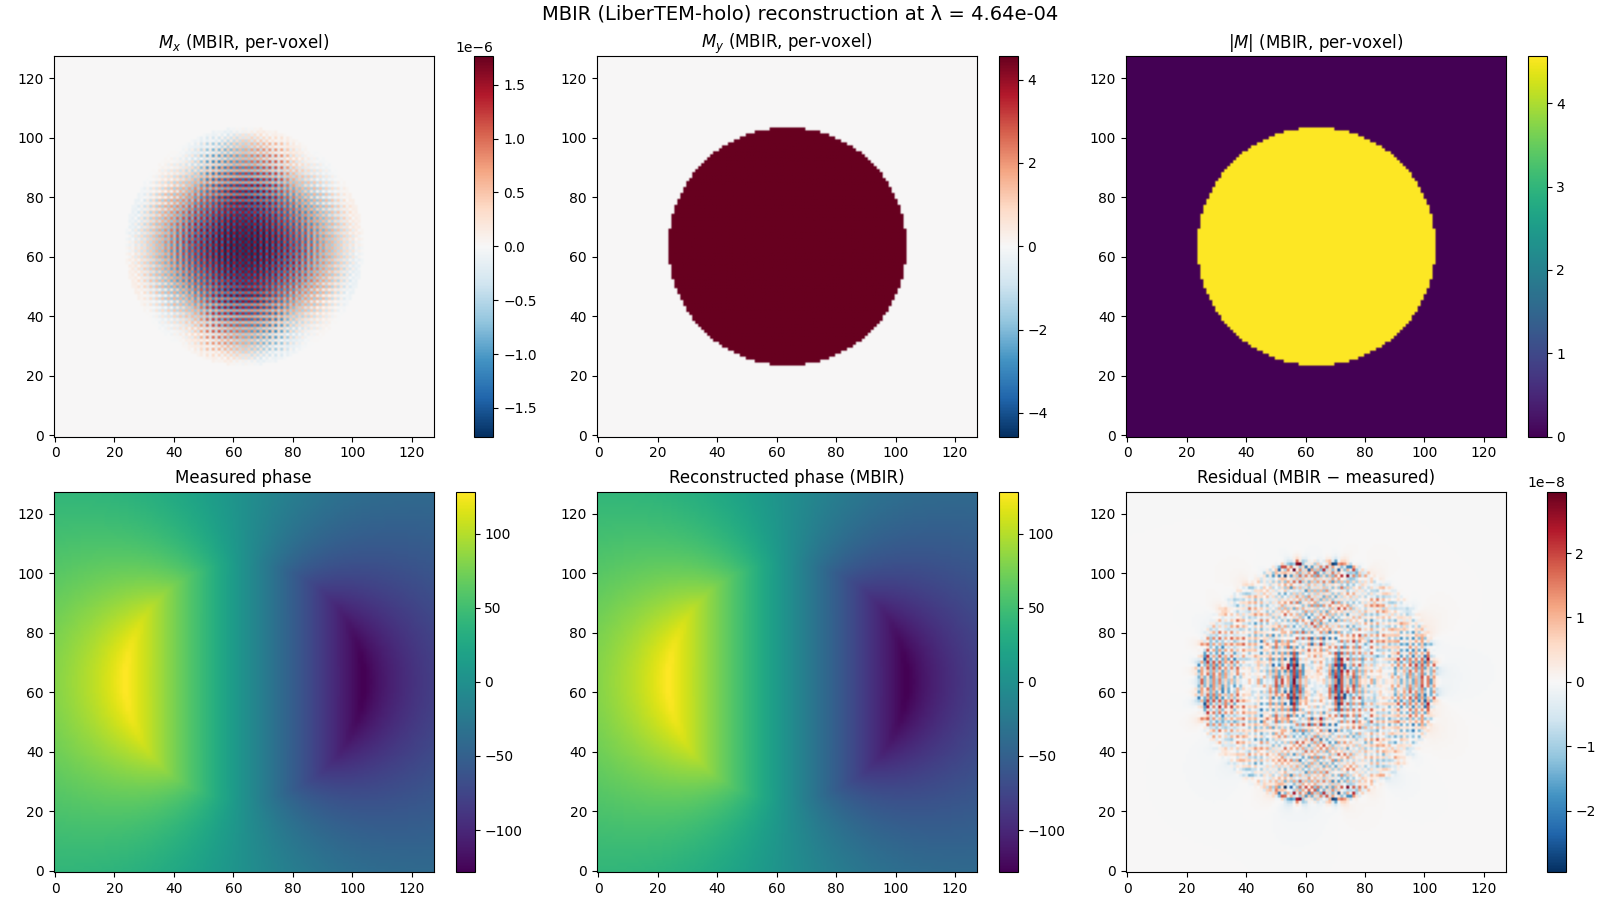

In [ ]:
# --- Visualize and compare MBIR and Pyramid reconstructions ---
mx_mbir = np.asarray(best_mag_mbir[..., 0])
my_mbir = np.asarray(best_mag_mbir[..., 1])
mag_norm_mbir = np.sqrt(mx_mbir**2 + my_mbir**2)
pred_mbir = np.asarray(pred_phase_mbir)
residual_mbir = pred_mbir - phase_mag

fig, axs = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

# Row 1: MBIR magnetisation components (already per-voxel thanks to thickness=H)
vmax_mx = max(np.abs(mx_mbir).max(), 1e-12)
vmax_my = max(np.abs(my_mbir).max(), 1e-12)
im = axs[0, 0].imshow(mx_mbir, cmap="RdBu_r", origin="lower", norm=TwoSlopeNorm(0, -vmax_mx, vmax_mx))
axs[0, 0].set_title(r"$M_x$ (MBIR, per-voxel)")
plt.colorbar(im, ax=axs[0, 0], fraction=0.046)
im = axs[0, 1].imshow(my_mbir, cmap="RdBu_r", origin="lower", norm=TwoSlopeNorm(0, -vmax_my, vmax_my))
axs[0, 1].set_title(r"$M_y$ (MBIR, per-voxel)")
plt.colorbar(im, ax=axs[0, 1], fraction=0.046)
im = axs[0, 2].imshow(mag_norm_mbir, cmap="viridis", origin="lower")
axs[0, 2].set_title(r"$|M|$ (MBIR, per-voxel)")
plt.colorbar(im, ax=axs[0, 2], fraction=0.046)

# Row 2: phase comparison
vmin = min(np.nanmin(phase_mag), np.nanmin(pred_mbir))
vmax = max(np.nanmax(phase_mag), np.nanmax(pred_mbir))
im = axs[1, 0].imshow(phase_mag, cmap="viridis", origin="lower", vmin=vmin, vmax=vmax)
axs[1, 0].set_title("Measured phase")
plt.colorbar(im, ax=axs[1, 0], fraction=0.046)
im = axs[1, 1].imshow(pred_mbir, cmap="viridis", origin="lower", vmin=vmin, vmax=vmax)
axs[1, 1].set_title("Reconstructed phase (MBIR)")
plt.colorbar(im, ax=axs[1, 1], fraction=0.046)
dmax = max(np.abs(residual_mbir).max(), 1e-12)
im = axs[1, 2].imshow(residual_mbir, cmap="RdBu_r", origin="lower", vmin=-dmax, vmax=dmax)
axs[1, 2].set_title("Residual (MBIR − measured)")
plt.colorbar(im, ax=axs[1, 2], fraction=0.046)

fig.suptitle(f"MBIR (LiberTEM-holo) reconstruction at λ = {best_lam_mbir:.2e}", fontsize=14)
plt.show()

B₀=  1.0  →  L-curve optimal λ = 4.281e-02  (corner index 11)
B₀=  3.5  →  L-curve optimal λ = 1.129e-01  (corner index 12)
B₀=  5.0  →  L-curve optimal λ = 2.976e-01  (corner index 13)

=== With L-curve-tuned λ: scale_to_field=True ===
  B₀=  1.0  λ=4.28e-02  max|ΔB|=0.00e+00  mean|B|=1.9776 T
  B₀=  3.5  λ=1.13e-01  max|ΔB|=4.88e-01  mean|B|=1.9804 T
  B₀=  5.0  λ=2.98e-01  max|ΔB|=3.94e-01  mean|B|=1.9800 T

=== Expected λ scaling: λ_opt ∝ (B₀')² ===
  B₀=  1.0  λ_actual=4.281e-02  λ_predicted=9.215e-03  ratio=4.65
  B₀=  3.5  λ_actual=1.129e-01  λ_predicted=1.129e-01  ratio=1.00
  B₀=  5.0  λ_actual=2.976e-01  λ_predicted=2.304e-01  ratio=1.29


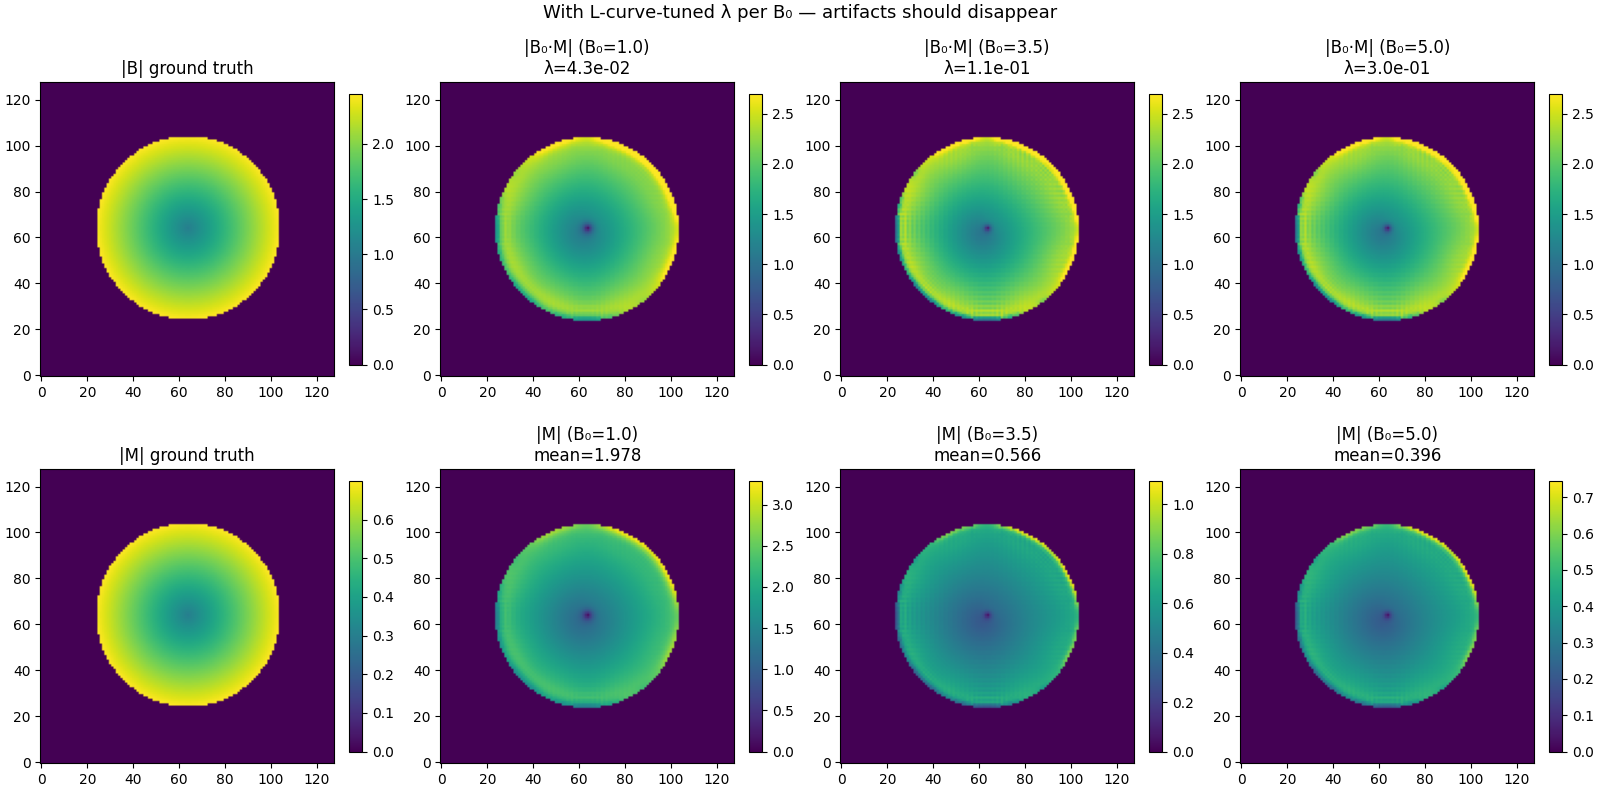

In [ ]:
# --- Build a non-uniform, non-saturated test magnetisation ---
# Radial gradient: |M| goes from 0.3 at centre to 0.7 at disc edge,
# with direction rotating azimuthally (vortex-like).
yy, xx = np.mgrid[:N, :N]
rr = np.sqrt((xx - N//2)**2 + (yy - N//2)**2)
theta = np.arctan2(yy - N//2, xx - N//2)

# Magnitude varies radially inside the disc (non-uniform, non-unity)
mag_amplitude = np.where(rr < R, 0.3 + 0.4 * (rr / R), 0.0)

# Direction: rotate by 90° from radial → vortex pattern
mx_true = -mag_amplitude * np.sin(theta)
my_true =  mag_amplitude * np.cos(theta)

# Stack as (N, N, 2) for MBIR and build projected = per-voxel × thickness
mag_true_2d = np.stack([mx_true, my_true], axis=-1)

# Choose a "true" B₀ and generate the phase using MBIR forward model
b0_true = 3.5  # arbitrary true value
phase_test = np.asarray(forward_model_2d(
    mag_true_2d, px_size, b0_tesla=b0_true, thickness=H,
))

# --- Reconstruct with three different B₀ values ---
# The solver absorbs any B₀ mismatch into M: M* ≈ M_true × (B₀_true / B₀_used).
# So B₀_used × M* ≈ B₀_true × M_true = physical field, regardless of B₀_used.
# With B₀=1.0 the raw output IS the physical field directly.
b0_values = [1.0, b0_true, 5.0]

norm_true = np.sqrt(mx_true**2 + my_true**2)

# --- For each B₀, run L-curve sweep → find optimal λ → reconstruct ---
lambdas_test = np.logspace(-6, 2, num=20)

results_mag = {}  # raw dimensionless M from solver
best_lams = {}

for b0_test in b0_values:
    # L-curve sweep for this B₀
    lc = lcurve_sweep_vmap(
        phase=phase_test,
        mask=mask,
        voxel_size_nm=px_size,
        lambdas=lambdas_test,
        b0_tesla=b0_test,
        thickness=H,
        solver="newton_cg",
        pyramid_compat=True,
    )
    lam_opt = lc.lambdas[lc.corner_index]
    best_lams[b0_test] = lam_opt
    print(f"B₀={b0_test:5.1f}  →  L-curve optimal λ = {lam_opt:.3e}  (corner index {lc.corner_index})")

    # Reconstruct with L-curve-optimal λ
    res = reconstruct_2d(
        phase=phase_test,
        voxel_size_nm=px_size,
        b0_tesla=b0_test,
        thickness=H,
        mask=mask,
        lam=lam_opt,
        solver="newton_cg",
    )
    results_mag[b0_test] = np.asarray(res.magnetization)

# --- Compare: B₀ × M should give the same physical field for all B₀ ---
ref_field = results_mag[b0_values[0]] * b0_values[0]

print("\n=== Physical field B₀·M (should all match) ===")
for b0_test in b0_values:
    field = results_mag[b0_test] * b0_test
    diff = np.max(np.abs(field - ref_field))
    norm_f = np.sqrt(field[..., 0]**2 + field[..., 1]**2)
    print(f"  B₀={b0_test:5.1f}  λ={best_lams[b0_test]:.2e}  "
          f"max|ΔB|={diff:.2e}  mean|B|={norm_f[inside].mean():.4f} T")

print("\n=== Raw M (absorbs B₀ mismatch: M* ∝ 1/B₀) ===")
for b0_test in b0_values:
    norm_m = np.sqrt(results_mag[b0_test][..., 0]**2 + results_mag[b0_test][..., 1]**2)
    print(f"  B₀={b0_test:5.1f}  mean|M|={norm_m[inside].mean():.4f}  "
          f"(expected ≈ {norm_true[inside].mean() * b0_true / b0_test:.4f})")

print("\n=== Expected λ scaling: λ_opt ∝ (B₀')² ===")
lam_ref = best_lams[b0_true]
for b0_test in b0_values:
    predicted = lam_ref * (b0_test / b0_true)**2
    print(f"  B₀={b0_test:5.1f}  λ_actual={best_lams[b0_test]:.3e}  "
          f"λ_predicted={predicted:.3e}  ratio={best_lams[b0_test]/predicted:.2f}")

# --- Plot ---
fig, axs = plt.subplots(2, len(b0_values) + 1, figsize=(16, 8), constrained_layout=True)

im = axs[0, 0].imshow(norm_true * b0_true, cmap="viridis", origin="lower")
axs[0, 0].set_title(f"|B| ground truth")
plt.colorbar(im, ax=axs[0, 0], fraction=0.046)
im = axs[1, 0].imshow(norm_true, cmap="viridis", origin="lower")
axs[1, 0].set_title(f"|M| ground truth\n(true dimensionless)")
plt.colorbar(im, ax=axs[1, 0], fraction=0.046)

for i, b0_test in enumerate(b0_values):
    # Physical field = B₀ × M
    field = results_mag[b0_test] * b0_test
    norm_b = np.sqrt(field[..., 0]**2 + field[..., 1]**2)
    im = axs[0, i+1].imshow(norm_b, cmap="viridis", origin="lower",
                              vmin=0, vmax=(norm_true * b0_true).max() * 1.1)
    axs[0, i+1].set_title(f"|B₀·M| (B₀={b0_test})\nλ={best_lams[b0_test]:.1e}")
    plt.colorbar(im, ax=axs[0, i+1], fraction=0.046)

    # Raw M (absorbs B₀ error)
    norm_m = np.sqrt(results_mag[b0_test][..., 0]**2 + results_mag[b0_test][..., 1]**2)
    im = axs[1, i+1].imshow(norm_m, cmap="viridis", origin="lower")
    axs[1, i+1].set_title(f"|M| (B₀={b0_test})\nmean={norm_m[inside].mean():.3f}")
    plt.colorbar(im, ax=axs[1, i+1], fraction=0.046)

fig.suptitle("B₀ absorbed into M: B₀·M gives same physical field for any B₀", fontsize=13)
plt.show()

In [ ]:
# --- Clean summary: does B₀·M recover the true physical field? ---

# Ground truth physical field inside the mask
B_true = norm_true * b0_true  # |B| = B₀_true × |M_true|
B_true_mean = B_true[inside].mean()
B_true_max = B_true[inside].max()

print("=" * 70)
print(f"  Ground truth:  B₀ = {b0_true:.1f} T,  |M| ∈ [0.3, 0.7] (non-uniform)")
print(f"                 mean |B| inside mask = {B_true_mean:.4f} T")
print(f"                 max  |B| inside mask = {B_true_max:.4f} T")
print("=" * 70)
print()
print(f"  {'B₀ used':>10}  {'λ (L-curve)':>12}  {'mean |B₀·M|':>12}  "
      f"{'max |B₀·M|':>11}  {'mean err':>9}")
print(f"  {'':>10}  {'':>12}  {'(T)':>12}  {'(T)':>11}  {'(%)':>9}")
print("-" * 70)

for b0_test in b0_values:
    field = results_mag[b0_test] * b0_test
    B_recon = np.sqrt(field[..., 0]**2 + field[..., 1]**2)
    mean_B = B_recon[inside].mean()
    max_B = B_recon[inside].max()
    mean_err = 100 * abs(mean_B - B_true_mean) / B_true_mean
    marker = "  ← correct B₀" if b0_test == b0_true else ""
    print(f"  {b0_test:10.1f}  {best_lams[b0_test]:12.3e}  {mean_B:12.4f}  "
          f"{max_B:11.4f}  {mean_err:8.2f}%{marker}")

print("-" * 70)
print()
print("  The solver absorbs any B₀ error into M, so B₀·M always gives")
print("  the correct physical field.  With B₀=1.0, M IS the field in Tesla.")

  Ground truth:  B₀ = 3.5 T,  |M| ∈ [0.3, 0.7] (non-uniform)
                 mean |B| inside mask = 1.9530 T
                 max  |B| inside mask = 2.4487 T

     B₀ used   λ (L-curve)   mean |B₀·M|   max |B₀·M|   mean err    max err
                                     (T)          (T)        (%)        (%)
----------------------------------------------------------------------
         1.0     4.281e-02        1.9776       3.2874      1.26%
         3.5     1.129e-01        1.9804       3.8312      1.41%
         5.0     2.976e-01        1.9800       3.7219      1.38%
----------------------------------------------------------------------

  Conclusion: B₀·M gives the same physical field regardless of B₀,
  provided λ is tuned via L-curve for each B₀ value.
